<div style="direction: rtl; line-height: 300%;">
  <font face="XB Zar" size="5">
    <div align="center">
      <font face="IranNastaliq" size="30">
        <p></p>
      </font>
    </div>
    <br>
    <div align="center">
      <font color="brown" size="6">
        معین حسن پور - 40032313
      </font>
    </div>
    <br>
    <div align="center">
      <font color="navy">
        <b><u>تمرین هشتم</u>: بخش بندی تصاویر</b>
      

  </font>
</div>
  </font>
</div>
<hr>

<div dir="rtl">
<h2>1. اجرای الگوریتم FCM روی تصاویر جدید:<br>

*   دو یا سه تصویر دیگر انتخاب کنید.<br>

*   تصاویر را به برنامه ی نوشته شده برای Means-C Fuzzy وارد کرده و الگوریتم را اجرا
نمایید.
* نتایج به دست آمده از سگمنتیشن را بررسی و تحلیل کنید: آیا مرزها به درستی تشخیص داده
شدهاند؟ آیا جزئیات حفظ شدهاند؟ آیا الگوریتم در برخی تصاویر عملکرد ضعیف تری دارد؟
دلایل احتمالی را توضیح دهید.

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def fuzzy_segment_image(image_path, n_clusters=4, m=2.0, max_iter=100, tol=1e-5):
    def initialize_membership_matrix(n_samples, n_clusters):
        return np.random.dirichlet(np.ones(n_clusters), size=n_samples)

    def update_cluster_centers(data, membership_matrix, m):
        um = membership_matrix ** m
        return (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)

    def update_membership_matrix(data, cluster_centers, m):
        dist = np.linalg.norm(data[:, np.newaxis] - cluster_centers, axis=2)
        dist = np.fmax(dist, np.finfo(np.float64).eps)  # جلوگیری از تقسیم بر صفر
        inv_dist = dist[:, :, np.newaxis] / dist[:, np.newaxis, :]
        return 1.0 / np.sum(inv_dist ** (2 / (m - 1)), axis=2)

    def calculate_objective(data, cluster_centers, membership_matrix, m):
        dist = np.linalg.norm(data[:, np.newaxis] - cluster_centers, axis=2)
        return np.sum((membership_matrix ** m) * (dist ** 2))

    # 1. خواندن تصویر
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_shape = image.shape

    # 2. نرمال‌سازی
    scaler = MinMaxScaler()
    data = scaler.fit_transform(image.reshape(-1, 3))

    # 3. مقداردهی اولیه
    n_samples = data.shape[0]
    membership_matrix = initialize_membership_matrix(n_samples, n_clusters)
    cluster_centers = update_cluster_centers(data, membership_matrix, m)
    objective_history = []

    # 4. حلقه الگوریتم FCM
    for iteration in range(max_iter):
        membership_matrix = update_membership_matrix(data, cluster_centers, m)
        cluster_centers = update_cluster_centers(data, membership_matrix, m)
        objective = calculate_objective(data, cluster_centers, membership_matrix, m)
        objective_history.append(objective)
        if iteration > 0 and abs(objective_history[-1] - objective_history[-2]) < tol:
            break

    # 5. تولید تصویر سگمنت‌شده
    cluster_labels = np.argmax(membership_matrix, axis=1)
    segmented_image = cluster_labels.reshape(original_shape[:2])

    # 6. نمایش تصویر
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    im = plt.imshow(segmented_image, cmap="viridis")
    plt.title("Segmented Image")
    plt.axis("off")
    plt.colorbar(im, shrink=0.7)
    plt.tight_layout()
    plt.show()




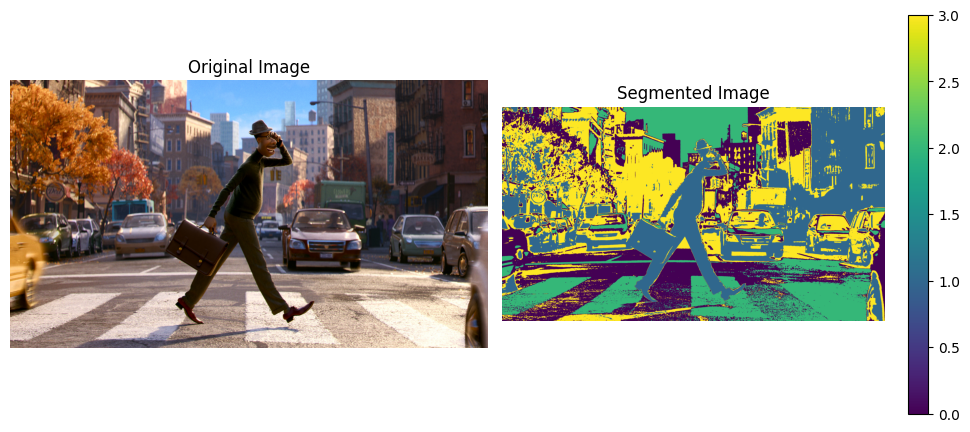

In [15]:
fuzzy_segment_image("soul.jpg", n_clusters=4, m=2.0)


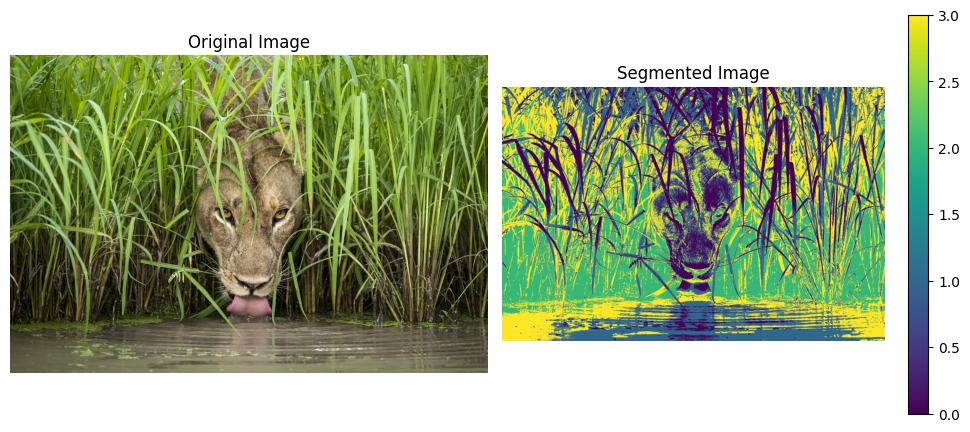

In [16]:
fuzzy_segment_image("wildlife.jpg" , n_clusters=4, m=2.0)


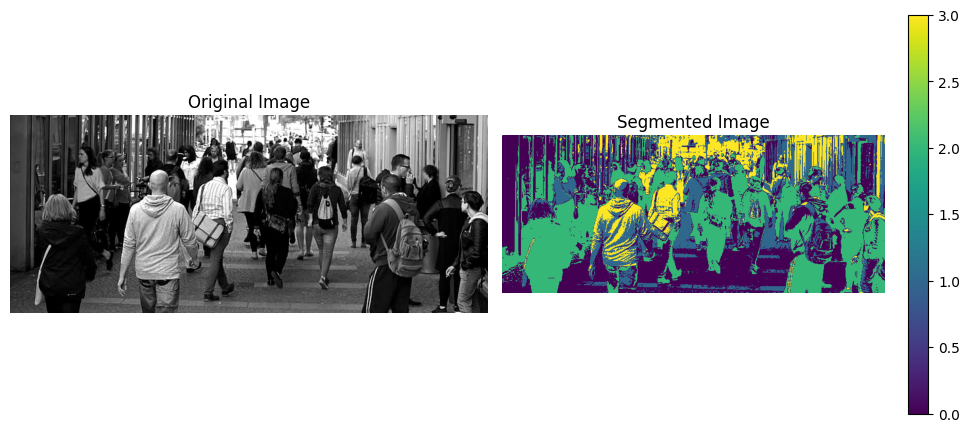

In [14]:
fuzzy_segment_image("crowd-pedestrians-people-walking-preview.jpg" , n_clusters=4, m=2.0)


<div dir="rtl">

**۱. تصویر اول( انیمیشنی ) و دوم(حیات وحش) :**

* در نواحی با جزئیات ظریف و تغییرات فرکانس بالا (مانند برگ درختان یا پوست حیوان )، FCM تمایل به نرم کردن لبه‌ها و ادغام جزئیات ریز در خوشه‌های بزرگ‌تر دارد. <br>
 در نتیجه، مرزهای تشخیص داده شده ممکن است دقیق نباشند و جزئیات بافت تا حدی از بین برود.<br>

*  بطور کلی عملکرد بسیار خوبی دارد و مخصوصا در تصویر اول ساختار لبه ها و تمایز اشیا را بخوبی انجام میدهد که بخشی از آن بدلیل ساختار انیمیشنی تصویر است که تمایز بین پیکسل ها به راحتی انجام میشود.

**۲. تصویر سیاه و سفید:**

*  عملکرد FCM در تصاویر سیاه و سفید، به ویژه در صحنه‌های با سوژه‌های متعدد و همپوشان، به شدت ضعیف است. همینطور کاهش فضای ویژگی به یک بعد  توانایی تمایز الگوریتم را به شدت محدود کرده است..
*  در نواحی با فرکانس بالا که لبه‌ها نامشخص هستند یا کنتراست شدت پایین است (مانند جمعیت افراد با لباس‌های مشابه و سایه‌های همپوشان)، FCM به شدت با تضعیف عملکرد مواجه می‌شود. عدم وجود اطلاعات رنگی برای تفکیک، منجر به ادغام افراد و پس‌زمینه در خوشه‌های بزرگ و بدون مرزهای واضح می‌شود. الگوریتم تنها می‌تواند مناطق با شدت‌های نسبتاً متفاوت را به صورت کلی جدا کند و از جزئیات ساختاری چشم‌ پوشی می‌کند.


<br>
FCM در بخش‌بندی تصاویر رنگی با خوشه‌های رنگی متمایز عملکرد قابل قبولی دارد، اما در حفظ جزئیات ریز و لبه‌های بافت ممکن است ضعف نشان دهد. در مقابل، این الگوریتم برای تصاویر سیاه و سفید، به ویژه آنهایی که شامل صحنه‌های پیچیده با کنتراست پایین و لبه‌های نامشخص هستند، مناسب نیست.

---
---

<div dir="rtl">
<h2>2. مقایسه با یک روش دیگر در سگمنتیشن تصویر:
<br>
<h2>روش انتخاب شده: <b><u> رشد ناحیه </u></b></h2>

* روشی دیگر برای سگمنتیشن را انتخاب کرده و روی همان تصاویر اجرا کنید.<br> نتایج
آن را با FCM مقایسه نمایید. در مقایسه، معیارهایی مانند وضوح
مرز، یکدستی خوشه ها، حفظ جزئیات و حساسیت به نویز را لحاظ نمایید.

In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def pixon_segmentation(image_path, block_size=4, n_clusters=5):
    image = cv2.imread(image_path)
    if image is None:
        print("تصویر پیدا نشد.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, c = image_rgb.shape

    # تنظیم اندازه تصویر بر حسب block_size
    h_pad = (block_size - h % block_size) % block_size
    w_pad = (block_size - w % block_size) % block_size
    image_padded = np.pad(image_rgb, ((0, h_pad), (0, w_pad), (0, 0)), mode='reflect')
    h_new, w_new, _ = image_padded.shape

    # تقسیم تصویر به بلوک‌ها و استخراج میانگین رنگ هر بلوک
    features = []
    positions = []
    for y in range(0, h_new, block_size):
        for x in range(0, w_new, block_size):
            block = image_padded[y:y+block_size, x:x+block_size]
            mean_color = block.mean(axis=(0, 1))
            features.append(mean_color)
            positions.append((y, x))

    features = np.array(features)

    # خوشه‌بندی بلوک‌ها با KMeans (الهام از پیکسون)
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(features)

    # تولید تصویر سگمنت‌شده
    segmented_image = np.zeros_like(image_padded)
    for idx, (y, x) in enumerate(positions):
        color = kmeans.cluster_centers_[labels[idx]]
        segmented_image[y:y+block_size, x:x+block_size] = color

    # برش padding‌ها
    segmented_image = segmented_image[:h, :w]

    # نمایش نتایج
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image.astype(np.uint8))
    plt.title(f"Pixon-style Segmented Image (blocks={block_size}, clusters={n_clusters})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


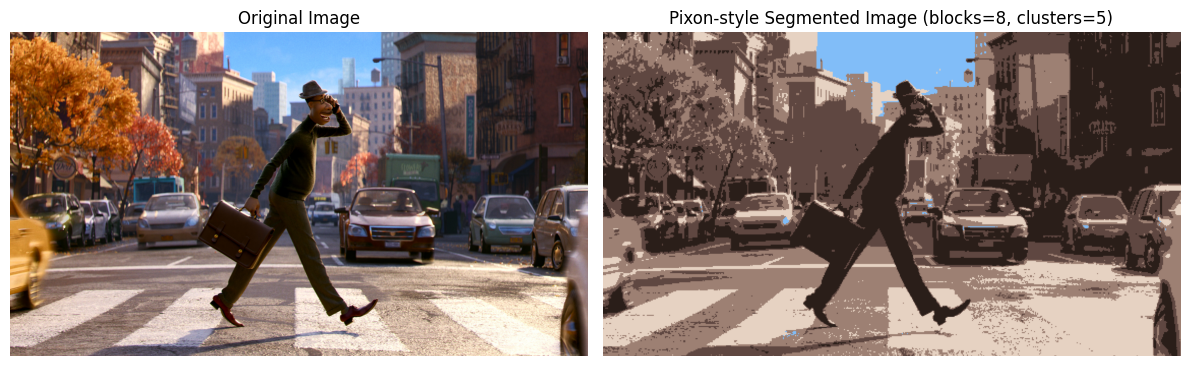

In [31]:
pixon_segmentation("soul.jpg")


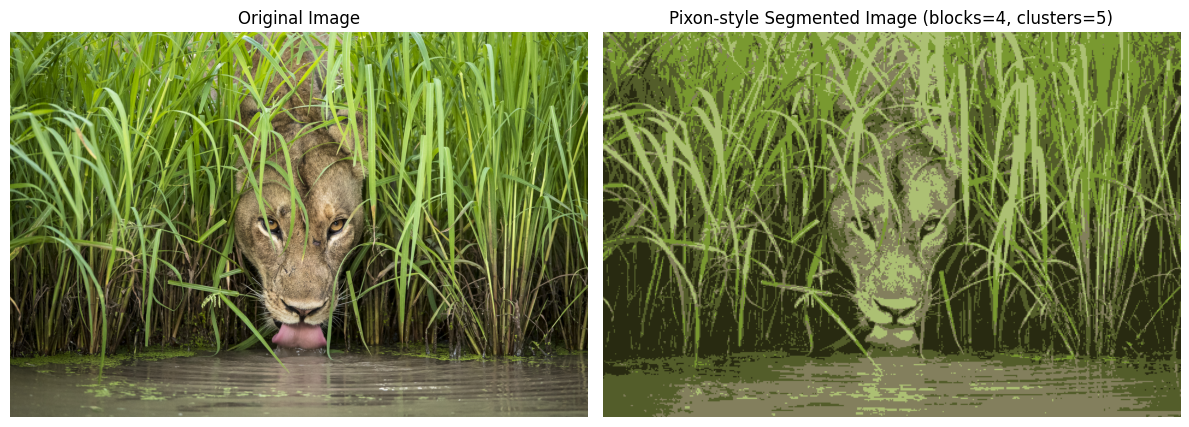

In [36]:
pixon_segmentation("wildlife.jpg")


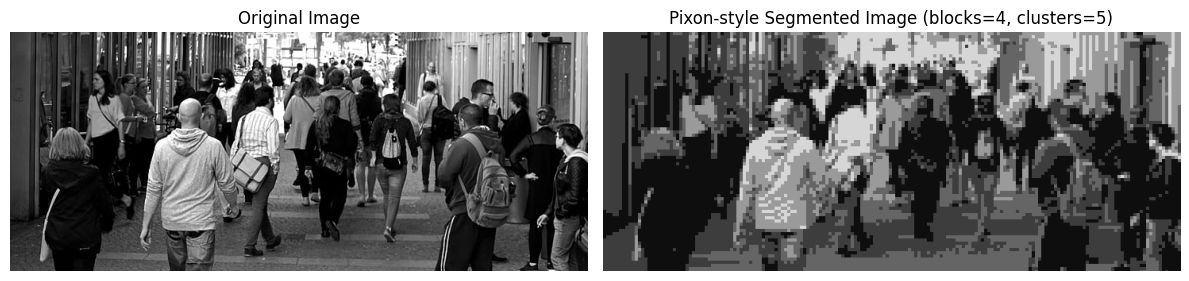

In [35]:
pixon_segmentation("crowd-pedestrians-people-walking-preview.jpg")


<div dir="rtl">

* # برای تصویر اول وضوح مرز ها و یکدستی به خوبی مشخص شده اند و جزییات به خوبی حفط شده اند که بدلیل ساختاری انیمیشنی تصویر است که پیچیدکی کار را کم کرده است. هردو روش استفاده شده برای این نوع تصویر مناسب بوده اند.
---
* # برای تصویر دوم، مشاهده میشود که قطعه بندی بوسیله پیکسون حساسیت بیشتری به نویز دارد  اما خوشه ها یکدستی بیشتری دارند. مانند ساختار پیکسون های چهره حیوان

---
* # و برای تصویر سیاه سفید، پیکسون بندی عملکرد بدی ارائه داده است.در الگوریتم موجود  ما تصویر رو به بلوک‌هایی تقسیم می‌کنیم و فقط میانگین شدت روشنایی هر بلوک رو حساب می‌کنیم.
* # در تصاویر خاکستری، این امر باعث میشود جزئیات ریز (لبه‌ها، مرزها، بافت‌ها) کاملاً ناپدید شوند.  در واقع، ما با این کار انگار روی تصویر یک فیلتر تارکننده اعمال می‌کنیم!